# Ensemble Learning 03 (2/2) — Bagging: Regression

Exactly the same as the bagging classifier, except that the final prediction is the **average** of the models'
predictions. All the same parameters apply: `n_estimators`, `max_samples`, `bootstrap`, `max_features`,
`bootstrap_features`, `oob_score`.

### In this notebook
1. A single tree vs bagging on a 1-D curve
2. Bagging vs other regressors on a non-linear dataset
3. More trees
4. OOB score and tuning

> 📖 Theory: [`theory.md`](theory.md) §1–3 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. One tree vs bagging

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

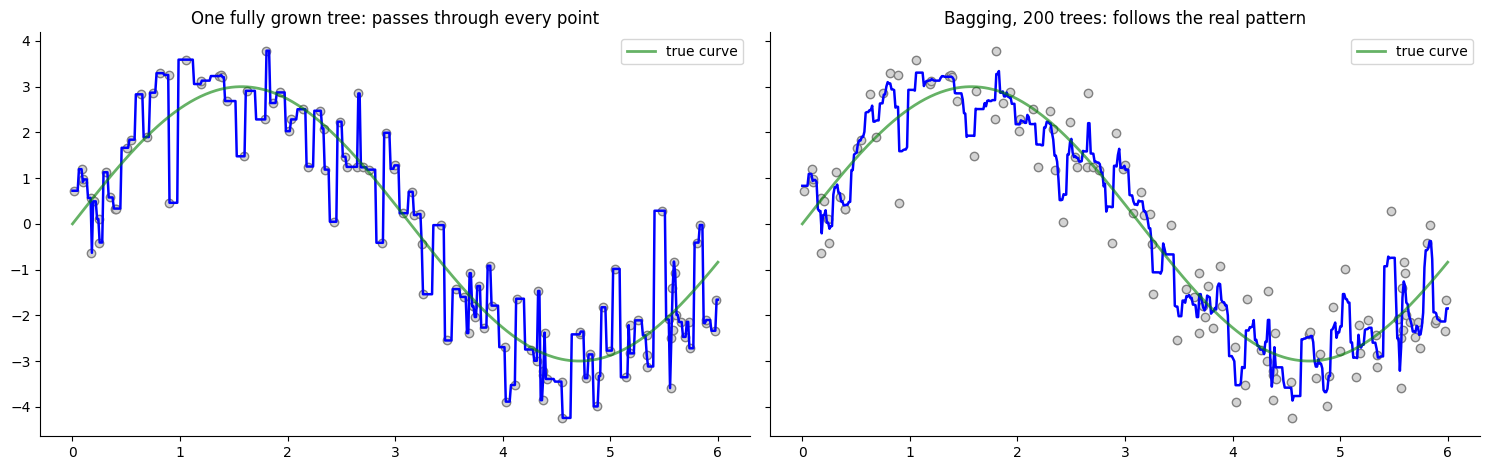

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 6, 120)).reshape(-1, 1)
y1 = np.sin(x).ravel() * 3 + rng.normal(0, 0.8, 120)
grid = np.linspace(0, 6, 500).reshape(-1, 1)

single = DecisionTreeRegressor(random_state=0).fit(x, y1)
bag = BaggingRegressor(DecisionTreeRegressor(), n_estimators=200, random_state=0).fit(x, y1)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, m, title in [(axes[0], single, 'One fully grown tree: passes through every point'),
                     (axes[1], bag, 'Bagging, 200 trees: follows the real pattern')]:
    ax.scatter(x, y1, color='lightgray', edgecolor='gray')
    ax.plot(grid, m.predict(grid), color='blue', linewidth=1.8)
    ax.plot(grid, 3 * np.sin(grid), color='green', linewidth=2, alpha=0.6, label='true curve')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

The single tree **chases the noise** (low bias, high variance). The average of 200 trees, each trained on a
different bootstrap sample, is much closer to the true curve.

## 2. Bagging vs other regressors

> ✍️ **Core code: learn this.** Compare single models with `BaggingRegressor` (default base model: a decision tree).

In [3]:
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

X, y = make_friedman1(n_samples=1000, noise=1.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'Bagging (10 trees, default)': BaggingRegressor(random_state=42),
    'Bagging (100 trees)': BaggingRegressor(n_estimators=100, random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    rows.append({'model': name, 'train R²': r2_score(y_train, m.predict(X_train)),
                 'test R²': r2_score(y_test, m.predict(X_test))})
pd.DataFrame(rows).round(3)

,model,train R²,test R²
0,Linear Regression,0.712,0.762
1,Decision Tree,1.000,0.624
2,KNN,0.781,0.660
3,"Bagging (10 trees, default)",0.963,0.836
4,Bagging (100 trees),0.975,0.849


- The single tree: **train R² = 1.0, test R² ≈ 0.62**, a textbook overfit.
- Bagging the same trees: test R² **≈ 0.85**, the best of all, even with the default 10 trees and no tuning.

## 3. How many trees?

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

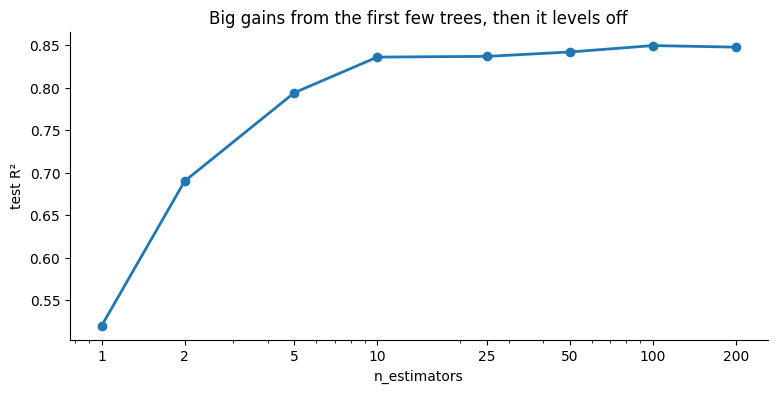

In [4]:
ns = [1, 2, 5, 10, 25, 50, 100, 200]
scores = [r2_score(y_test, BaggingRegressor(n_estimators=n, random_state=42).fit(X_train, y_train).predict(X_test))
          for n in ns]
plt.figure(figsize=(9, 4))
plt.plot(ns, scores, 'o-', linewidth=2)
plt.xscale('log')
plt.xticks(ns, ns)
plt.xlabel('n_estimators')
plt.ylabel('test R²')
plt.title('Big gains from the first few trees, then it levels off')
plt.show()

## 4. OOB score and tuning

> ✍️ **Core code: learn this.** OOB works for regression too (it reports R²).

In [5]:
bag = BaggingRegressor(n_estimators=200, oob_score=True, random_state=42, n_jobs=-1).fit(X_train, y_train)
print("OOB R² :", round(bag.oob_score_, 3))
print("Test R²:", round(bag.score(X_test, y_test), 3))

OOB R² : 0.821
Test R²: 0.848


> ✍️ **Core code: learn this.** Tune the base model and the sampling settings together.

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'estimator': [DecisionTreeRegressor(), KNeighborsRegressor()],
    'n_estimators': [50, 100],
    'max_samples': [0.5, 1.0],
    'max_features': [0.5, 1.0],
    'bootstrap': [True, False],
}
search = GridSearchCV(BaggingRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV R²     :", round(search.best_score_, 3))
print("Test R²        :", round(search.score(X_test, y_test), 3))

Best parameters: {'bootstrap': True, 'estimator': DecisionTreeRegressor(), 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 100}
Best CV R²     : 0.803
Test R²        : 0.849


---
## Key takeaways
- `BaggingRegressor` = many models on bootstrap samples, **averaged**.
- It turns an overfitting tree (test R² 0.62) into a strong model (≈ 0.85) with no tuning.
- Same parameters and OOB score as the classifier; tune them with `GridSearchCV`.
- Random Forest Regression (`../04-random-forest/`) is the most popular implementation of this idea.

## 🎓 Next steps in the ensemble journey
| Topic | Where |
|---|---|
| Random Forest (bagging + random features) | [`../04-random-forest/`](../04-random-forest/) |
| Boosting: AdaBoost | [`../05-adaboost/`](../05-adaboost/) |
| Boosting: Gradient Boosting | [`../06-gradient-boosting/`](../06-gradient-boosting/) |
| Boosting: XGBoost | [`../07-xgboost/`](../07-xgboost/) |
| Stacking & Blending | [`../08-stacking-and-blending/`](../08-stacking-and-blending/) |